# Lab 8: Categorical Naive Bayes on the Play Tennis Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load dataset
df = pd.read_csv("Lab 8 - Sheet1.csv")
df = df.drop(columns=["No"])
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


## 1. Separate input features and target variable

In [3]:
X = df[["Outlook", "Temperature", "Humidity", "Wind"]]
y = df["Play Tennis"]

print("Input features (X):")
display(X.head())
print("\nTarget variable (y):")
print(y.head())

Input features (X):


,Outlook,Temperature,Humidity,Wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak



Target variable (y):
0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: str


## 2. Encode categorical values into numerical values

In [4]:
ordinal_encoder = OrdinalEncoder()
X_encoded = ordinal_encoder.fit_transform(X)
X_encoded = pd.DataFrame(X_encoded, columns=X.columns, dtype=int)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded features:")
display(X_encoded.head())

print("\nEncoding scheme learned per feature:")
for col, categories in zip(X.columns, ordinal_encoder.categories_):
    print(f"  {col}: {list(categories)} -> {list(range(len(categories)))}")

print("\nTarget classes:", list(label_encoder.classes_), "-> ", list(range(len(label_encoder.classes_))))

Encoded features:


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1



Encoding scheme learned per feature:
  Outlook: ['Overcast', 'Rain', 'Sunny'] -> [0, 1, 2]
  Temperature: ['Cool', 'Hot', 'Mild'] -> [0, 1, 2]
  Humidity: ['High', 'Normal'] -> [0, 1]
  Wind: ['Strong', 'Weak'] -> [0, 1]

Target classes: ['No', 'Yes'] ->  [0, 1]


## 3. Split into training and testing sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 35
Testing set size: 15


## 4. Train a Categorical Naive Bayes model

In [6]:
nb_model = CategoricalNB()
nb_model.fit(X_train, y_train)

CategoricalNB()

## 5. Predict on the test set and evaluate

In [7]:
y_pred_nb = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
print("Categorical Naive Bayes Accuracy:", round(nb_accuracy * 100, 2), "%")

Categorical Naive Bayes Accuracy: 86.67 %


Confusion Matrix:
 [[ 3  2]
 [ 0 10]]


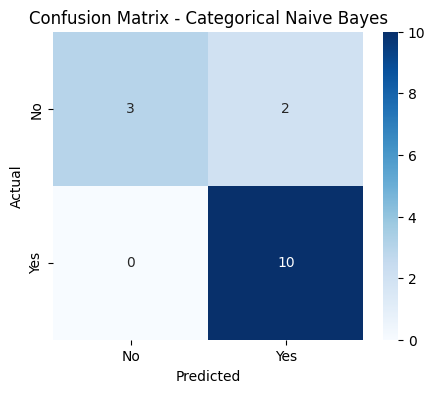


Classification Report:

              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15



In [8]:
cm = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Categorical Naive Bayes")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_))

## 6. Predict for a new weather condition

Outlook: Sunny, Temperature: Cool, Humidity: High, Wind: Strong

In [9]:
new_sample = pd.DataFrame(
    [["Sunny", "Cool", "High", "Strong"]],
    columns=["Outlook", "Temperature", "Humidity", "Wind"]
)

new_sample_encoded = pd.DataFrame(
    ordinal_encoder.transform(new_sample), columns=new_sample.columns
)

predicted_class = nb_model.predict(new_sample_encoded)
predicted_proba = nb_model.predict_proba(new_sample_encoded)

print("New weather condition:", dict(zip(new_sample.columns, new_sample.iloc[0])))
print("\nPredicted class:", label_encoder.inverse_transform(predicted_class)[0])

print("\nClass probabilities:")
for cls, prob in zip(label_encoder.classes_, predicted_proba[0]):
    print(f"  {cls}: {prob:.4f}")

New weather condition: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'}

Predicted class: No

Class probabilities:
  No: 0.7466
  Yes: 0.2534


## 7. Compare performance with Decision Tree and Logistic Regression

In [10]:
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")
print("\nDecision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Decision Tree Accuracy: 100.0 %

Decision Tree Classification Report:

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00        10

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Logistic Regression Accuracy: 93.33 %

Logistic Regression Classification Report:

              precision    recall  f1-score   support

          No       1.00      0.80      0.89         5
         Yes       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



C:\Users\ncmia\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


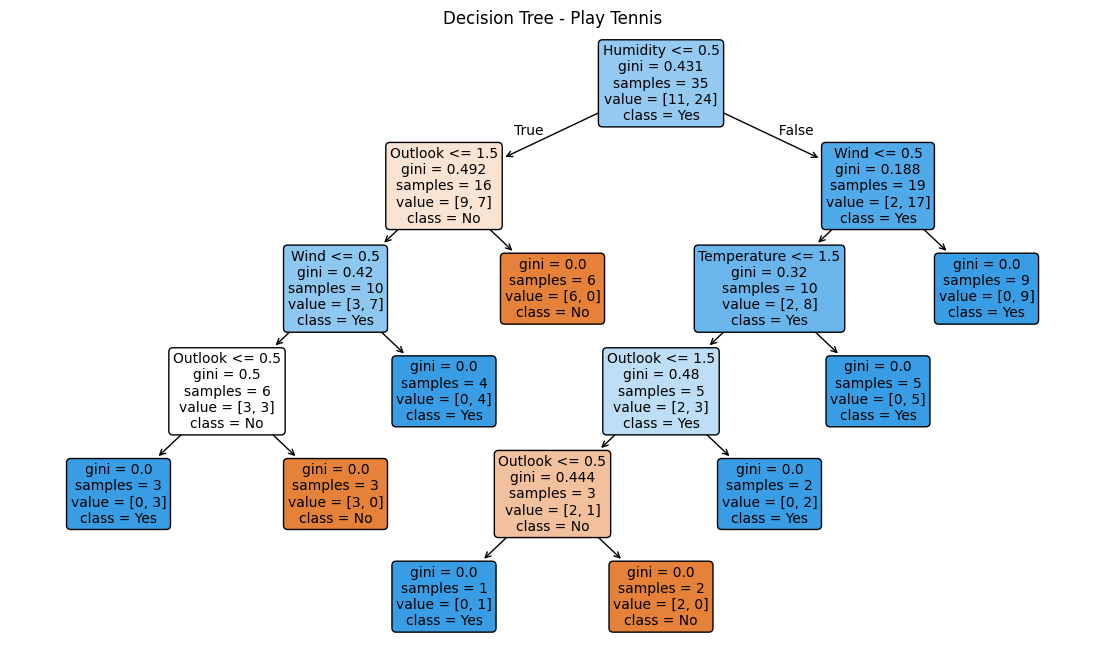

In [11]:
plt.figure(figsize=(14, 8))
plot_tree(dt_model, feature_names=X.columns, class_names=label_encoder.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree - Play Tennis")
plt.show()

,Model,Accuracy
0,Decision Tree,1.000000
1,Logistic Regression,0.933333
2,Categorical Naive Bayes,0.866667


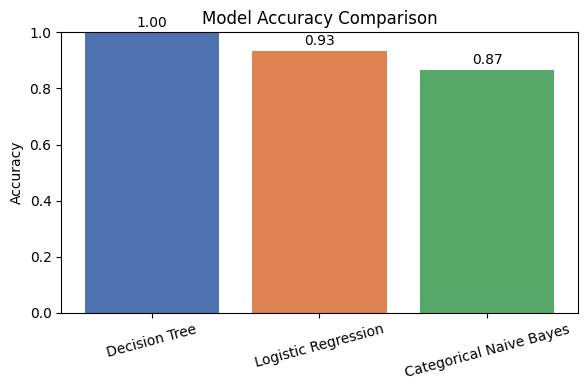

In [12]:
comparison_df = pd.DataFrame({
    "Model": ["Categorical Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Accuracy": [nb_accuracy, dt_accuracy, lr_accuracy]
}).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(comparison_df)

plt.figure(figsize=(6, 4))
bars = plt.bar(comparison_df["Model"], comparison_df["Accuracy"],
                color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
for bar, acc in zip(bars, comparison_df["Accuracy"]):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f"{acc:.2f}", ha="center")
plt.tight_layout()
plt.show()